# 3 PCA Analysis

This notebook extracts latent attention factors from the filtered Google Trends keyword panel using Principal Component Analysis (PCA). Dates are observations, keywords are variables, and each keyword series is standardized before PCA so high-volume searches do not mechanically dominate the components.

The outputs from this notebook are:

1. `data/processed/pca_scores.csv`: monthly principal component scores,
2. `data/processed/pca_loadings.csv`: keyword loadings for each component,
3. visual checks of explained variance and component stability over time.


In [1]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    print("Using scikit-learn PCA and StandardScaler")
except ModuleNotFoundError:
    print("scikit-learn not found; using NumPy PCA fallback")

    class StandardScaler:
        def fit(self, X):
            X = np.asarray(X, dtype=float)
            self.mean_ = X.mean(axis=0)
            self.scale_ = X.std(axis=0, ddof=0)
            self.scale_[self.scale_ == 0] = 1.0
            return self

        def transform(self, X):
            return (np.asarray(X, dtype=float) - self.mean_) / self.scale_

        def fit_transform(self, X):
            return self.fit(X).transform(X)

    class PCA:
        def __init__(self, n_components=None):
            self.n_components = n_components

        def fit(self, X):
            X = np.asarray(X, dtype=float)
            self.mean_ = X.mean(axis=0)
            X_centered = X - self.mean_
            _, s, vt = np.linalg.svd(X_centered, full_matrices=False)
            n_keep = self.n_components or vt.shape[0]
            self.components_ = vt[:n_keep]
            explained_variance = (s ** 2) / (X.shape[0] - 1)
            self.explained_variance_ = explained_variance[:n_keep]
            self.explained_variance_ratio_ = explained_variance[:n_keep] / explained_variance.sum()
            self.n_components_ = n_keep
            return self

        def transform(self, X):
            X_centered = np.asarray(X, dtype=float) - self.mean_
            return X_centered @ self.components_.T

        def fit_transform(self, X):
            return self.fit(X).transform(X)


scikit-learn not found; using NumPy PCA fallback


In [2]:
# File paths and analysis settings.
# The project-root lookup keeps the notebook runnable from either the repo root or notebooks/.
PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd(), Path.cwd().parent]
    if (candidate / "data/processed/trends_final_filtered.csv").exists()
)
PROCESSED_DATA_DIR = PROJECT_ROOT / "data/processed"

TRENDS_FILTERED_PATH = PROCESSED_DATA_DIR / "trends_final_filtered.csv"
PCA_SCORES_PATH = PROCESSED_DATA_DIR / "pca_scores.csv"
PCA_LOADINGS_PATH = PROCESSED_DATA_DIR / "pca_loadings.csv"

N_DISPLAY_COMPONENTS = 20
N_STABILITY_PCS = 13
ROLLING_WINDOW = 36


## Load PCA Input Panel

`2_preprocessing_data.ipynb` saves a keyword-by-month matrix. For PCA, the matrix is transposed so rows are monthly observations and columns are keyword features.


In [3]:
# Load the filtered keyword panel produced by the preprocessing notebook.
trends_keywords = pd.read_csv(TRENDS_FILTERED_PATH, index_col=0)
trends_keywords.columns = pd.to_datetime(trends_keywords.columns)
trends_keywords = trends_keywords.apply(pd.to_numeric, errors="coerce").fillna(0)

print(f"Filtered keyword panel: {trends_keywords.shape}")
print(f"Keywords: {trends_keywords.shape[0]:,}")
print(f"Monthly observations: {trends_keywords.shape[1]:,}")
print(f"Date range: {trends_keywords.columns.min().date()} to {trends_keywords.columns.max().date()}")
print(f"Stock market anchor present: {'stock market' in trends_keywords.index}")

trends_keywords.iloc[:5, :5]


Filtered keyword panel: (163, 121)
Keywords: 163
Monthly observations: 121
Date range: 2016-05-01 to 2026-05-01
Stock market anchor present: False


,2016-05-01,2016-06-01,2016-07-01,2016-08-01,2016-09-01
keyword,,,,,
5g,9.090909,6.666667,10.0,11.111111,10.0
advertising,81.818182,53.333333,80.0,88.888889,90.0
aerospace,27.272727,20.000000,30.0,33.333333,30.0
airlines,1540.000000,1071.428571,1500.0,1825.000000,1575.0
aluminum,172.727273,126.666667,180.0,200.000000,190.0


In [4]:
# Orient data for PCA: observations = dates, variables = keywords.
trends_data = trends_keywords.T.sort_index()
trends_data.index.name = "date"

# Constant keyword series have no variance, so they cannot contribute to standardized PCA.
constant_cols = trends_data.columns[trends_data.nunique(dropna=False) <= 1].tolist()
if constant_cols:
    print(f"Dropping {len(constant_cols)} constant keyword columns")
    trends_data = trends_data.drop(columns=constant_cols)

print(f"PCA input shape: {trends_data.shape}")
print(f"Observations: {trends_data.shape[0]:,}")
print(f"Keyword variables: {trends_data.shape[1]:,}")

trends_data.describe().T[["mean", "std", "min", "max"]].head(10)


PCA input shape: (121, 163)
Observations: 121
Keyword variables: 163


,mean,std,min,max
keyword,,,,
5g,43.407623,25.603173,4.000000,100.000000
advertising,42.110629,18.057236,7.000000,90.000000
aerospace,18.710454,6.626277,3.000000,33.333333
airlines,802.393502,377.310828,121.739130,1825.000000
aluminum,112.779797,37.791868,17.000000,200.000000
amazon stock,35.156272,11.731941,11.111111,62.962963
amd stock,18.960312,9.639510,4.000000,63.157895
api,92.154099,38.642694,13.000000,246.666667
apple stock,33.022056,12.733476,12.000000,100.000000


## Estimate PCA

Each keyword series is standardized to mean zero and unit variance before PCA. Component signs are arbitrary, so interpretation should focus on relative magnitudes and groups of high-loading keywords rather than the raw sign alone.


In [5]:
# Run PCA on standardized keyword series.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(trends_data)

pca = PCA()
pc_values = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

explained_variance_summary = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, len(explained_variance) + 1)],
    "Variance explained (%)": explained_variance,
    "Cumulative variance explained (%)": cumulative_variance,
})

print(f"PCA completed with {pca.n_components_} components")
print(f"First 1 PC: {cumulative_variance[0]:.2f}% cumulative variance")
print(f"First 5 PCs: {cumulative_variance[4]:.2f}% cumulative variance")
print(f"First 10 PCs: {cumulative_variance[9]:.2f}% cumulative variance")

explained_variance_summary.head(N_DISPLAY_COMPONENTS)


PCA completed with 121 components
First 1 PC: 56.10% cumulative variance
First 5 PCs: 81.13% cumulative variance
First 10 PCs: 88.26% cumulative variance


,PC,Variance explained (%),Cumulative variance explained (%)
0,PC1,56.097000,56.097000
1,PC2,13.651378,69.748377
2,PC3,5.775552,75.523930
3,PC4,3.435049,78.958979
4,PC5,2.173120,81.132099
5,PC6,1.841023,82.973122
6,PC7,1.732429,84.705551
7,PC8,1.385914,86.091465
8,PC9,1.167276,87.258741
9,PC10,1.001936,88.260677


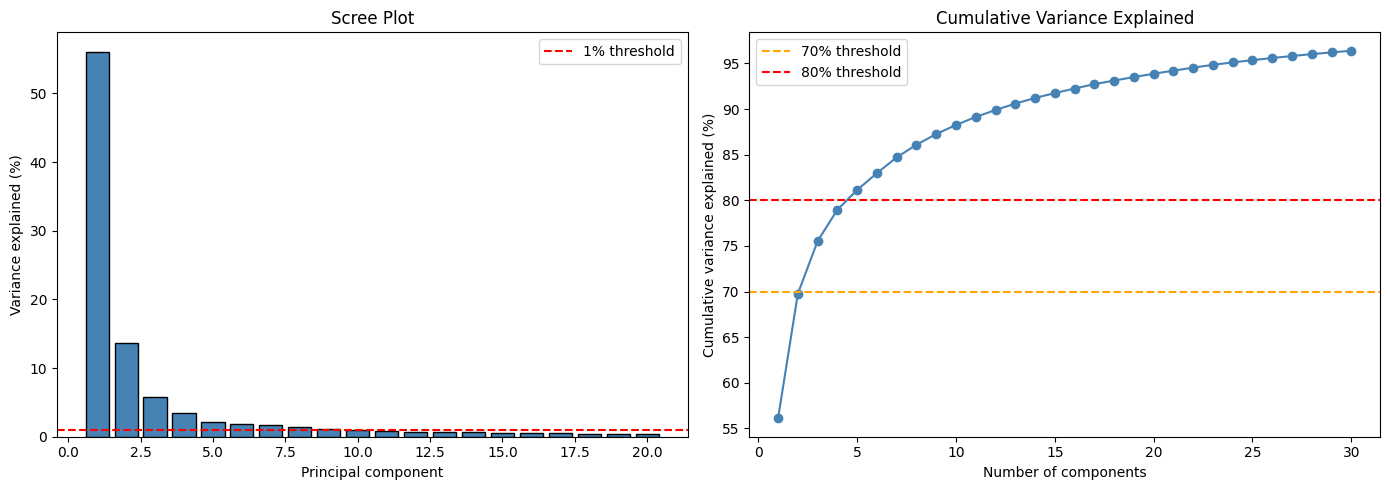

70% variance explained by 3 components
80% variance explained by 5 components
90% variance explained by 13 components


In [6]:
# Scree and cumulative variance plots.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_bar = min(N_DISPLAY_COMPONENTS, len(explained_variance))
ax1.bar(range(1, n_bar + 1), explained_variance[:n_bar], color="steelblue", edgecolor="black")
ax1.axhline(y=1, color="red", linestyle="--", label="1% threshold")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Variance explained (%)")
ax1.set_title("Scree Plot")
ax1.legend()

n_line = min(30, len(cumulative_variance))
ax2.plot(range(1, n_line + 1), cumulative_variance[:n_line], marker="o", color="steelblue")
ax2.axhline(y=70, color="orange", linestyle="--", label="70% threshold")
ax2.axhline(y=80, color="red", linestyle="--", label="80% threshold")
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative variance explained (%)")
ax2.set_title("Cumulative Variance Explained")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"70% variance explained by {np.argmax(cumulative_variance >= 70) + 1} components")
print(f"80% variance explained by {np.argmax(cumulative_variance >= 80) + 1} components")
print(f"90% variance explained by {np.argmax(cumulative_variance >= 90) + 1} components")


## Save Scores and Loadings

The PC scores are the time-series factors used in later predictive tests. The loadings show which keywords contribute most to each component.


In [7]:
# Save PC scores and keyword loadings.
pca_scores = pd.DataFrame(
    pc_values,
    index=trends_data.index,
    columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)],
)

loadings = pd.DataFrame(
    pca.components_.T,
    index=trends_data.columns,
    columns=[f"PC{i}" for i in range(1, pca.components_.shape[0] + 1)],
)

pca_scores.to_csv(PCA_SCORES_PATH)
loadings.to_csv(PCA_LOADINGS_PATH)

print(f"PCA scores saved to: {PCA_SCORES_PATH.name}")
print(f"PCA scores shape: {pca_scores.shape}  (dates x PCs)")
print(f"PCA loadings saved to: {PCA_LOADINGS_PATH.name}")
print(f"Loadings shape: {loadings.shape}  (keywords x PCs)")

pca_scores.iloc[:5, :5]


PCA scores saved to: pca_scores.csv
PCA scores shape: (121, 121)  (dates x PCs)
PCA loadings saved to: pca_loadings.csv
Loadings shape: (163, 121)  (keywords x PCs)


,PC1,PC2,PC3,PC4,PC5
date,,,,,
2016-05-01,15.270874,7.058147,3.219538,-0.661107,2.313337
2016-06-01,1.711560,6.787314,1.805027,-2.083383,3.336154
2016-07-01,17.449749,7.474903,-0.190481,-4.443894,2.812046
2016-08-01,22.880848,7.531968,1.081817,-3.988857,2.021328
2016-09-01,18.340890,6.591766,4.402958,0.554895,-0.400135


In [8]:
# Inspect the highest absolute keyword loadings for the first five PCs.
top_loading_rows = []
for pc in [f"PC{i}" for i in range(1, 6)]:
    top_keywords = loadings[pc].abs().sort_values(ascending=False).head(15).index
    for keyword in top_keywords:
        loading = loadings.loc[keyword, pc]
        top_loading_rows.append({
            "PC": pc,
            "keyword": keyword,
            "loading": loading,
            "absolute_loading": abs(loading),
        })

top_loadings = pd.DataFrame(top_loading_rows)
top_loadings.head(75)


,PC,keyword,loading,absolute_loading
0,PC1,copper,0.102522,0.102522
1,PC1,construction,0.102416,0.102416
2,PC1,logistics,0.100785,0.100785
3,PC1,manufacturing,0.100711,0.100711
4,PC1,oncology,0.100708,0.100708
...,...,...,...,...
70,PC5,derivative,-0.168832,0.168832
71,PC5,infrastructure,-0.156024,0.156024
72,PC5,gas price,0.150223,0.150223
73,PC5,mining,-0.145716,0.145716


## PCA Stability Over Time

The first stability check plots the first 13 PC score series. The rolling-window check refits PCA over 36-month windows and compares each rolling loading vector to the full-sample loading vector using absolute cosine similarity, so sign flips do not count as instability.


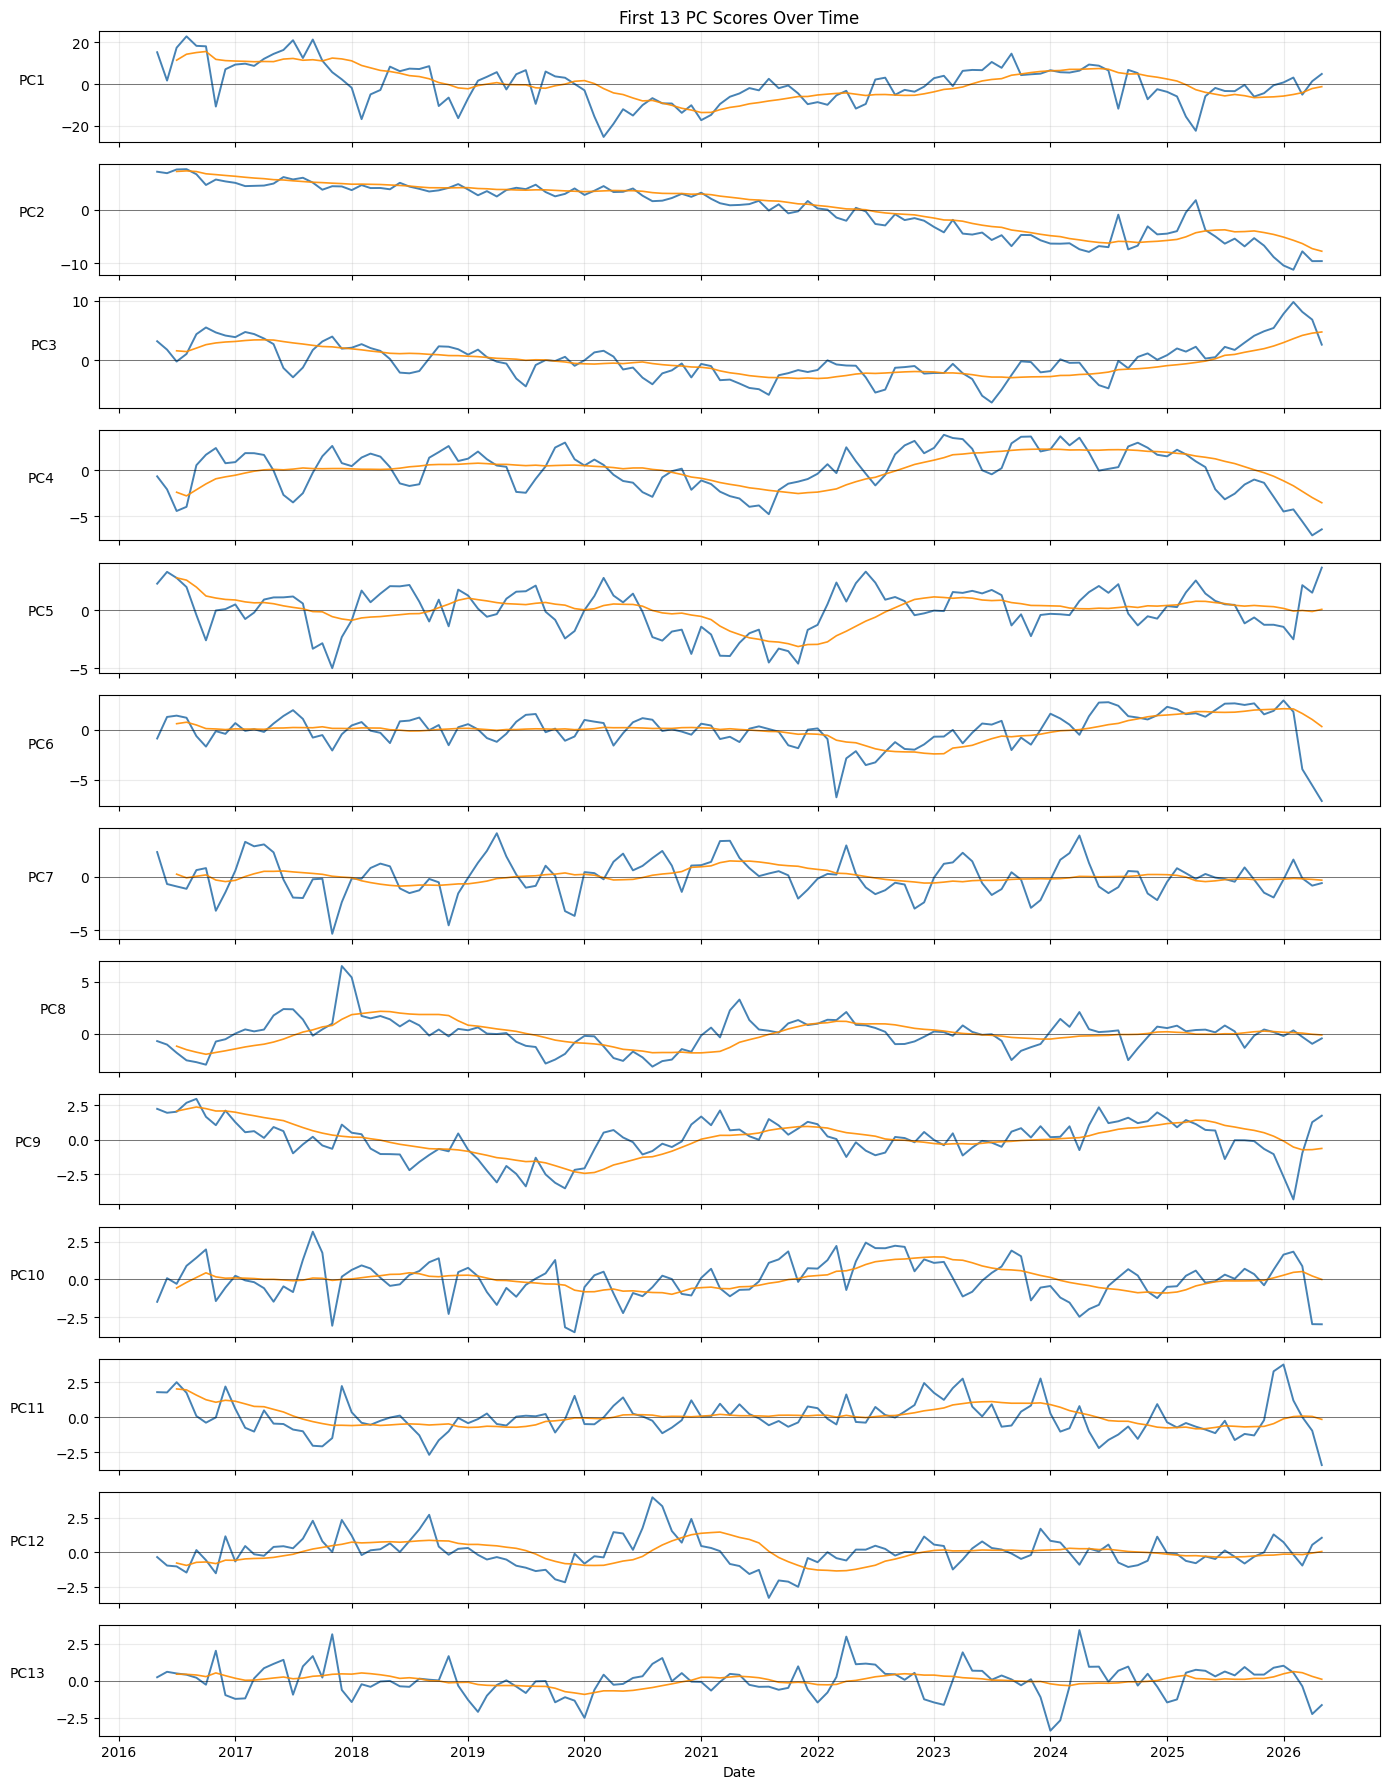

In [9]:
# Plot first 13 PC score time series.
score_cols = [f"PC{i}" for i in range(1, N_STABILITY_PCS + 1)]
scores_13 = pca_scores[score_cols]

fig, axes = plt.subplots(N_STABILITY_PCS, 1, figsize=(14, 18), sharex=True)
for ax, pc in zip(axes, score_cols):
    ax.plot(scores_13.index, scores_13[pc], color="steelblue", linewidth=1.4)
    ax.plot(
        scores_13.index,
        scores_13[pc].rolling(12, min_periods=3).mean(),
        color="darkorange",
        linewidth=1.2,
        alpha=0.9,
    )
    ax.axhline(0, color="black", linewidth=0.7, alpha=0.5)
    ax.set_ylabel(pc, rotation=0, labelpad=20)
    ax.grid(True, alpha=0.25)

axes[0].set_title("First 13 PC Scores Over Time")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


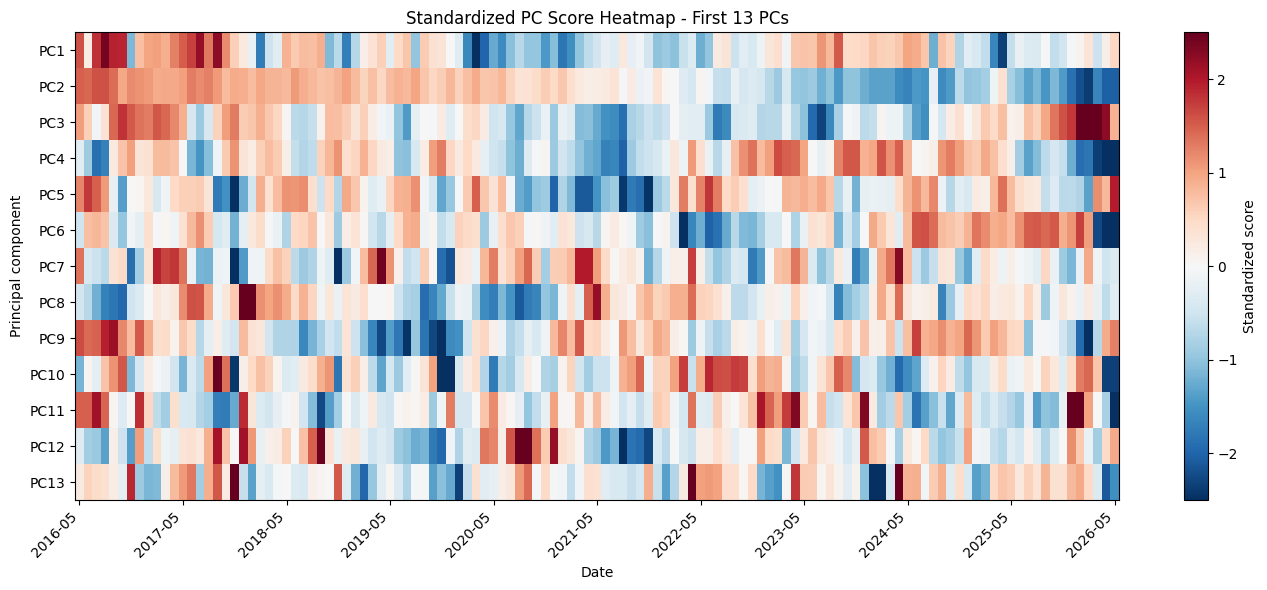

In [10]:
# Heatmap of standardized first 13 PC scores.
scores_13_z = (scores_13 - scores_13.mean()) / scores_13.std(ddof=0)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(
    scores_13_z.T,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2.5,
    vmax=2.5,
)

ax.set_yticks(range(N_STABILITY_PCS))
ax.set_yticklabels(score_cols)

xticks = np.arange(0, len(scores_13_z.index), 12)
ax.set_xticks(xticks)
ax.set_xticklabels([scores_13_z.index[i].strftime("%Y-%m") for i in xticks], rotation=45, ha="right")
ax.set_title("Standardized PC Score Heatmap - First 13 PCs")
ax.set_xlabel("Date")
ax.set_ylabel("Principal component")
plt.colorbar(im, ax=ax, label="Standardized score")
plt.tight_layout()
plt.show()


In [11]:
# Rolling-window loading stability against full-sample PCA loadings.
full_components = pca.components_[:N_STABILITY_PCS]
rolling_same_rank = []
rolling_best_match = []
rolling_dates = []

for end_pos in range(ROLLING_WINDOW, len(trends_data) + 1):
    window_data = trends_data.iloc[end_pos - ROLLING_WINDOW:end_pos]
    X_window = StandardScaler().fit_transform(window_data)

    pca_window = PCA(n_components=N_STABILITY_PCS)
    pca_window.fit(X_window)
    window_components = pca_window.components_[:N_STABILITY_PCS]

    same_rank_row = []
    best_match_row = []
    for i in range(N_STABILITY_PCS):
        similarities = np.abs(window_components @ full_components[i])
        same_rank_row.append(similarities[i])
        best_match_row.append(similarities.max())

    rolling_same_rank.append(same_rank_row)
    rolling_best_match.append(best_match_row)
    rolling_dates.append(trends_data.index[end_pos - 1])

same_rank_stability = pd.DataFrame(rolling_same_rank, index=rolling_dates, columns=score_cols)
best_match_stability = pd.DataFrame(rolling_best_match, index=rolling_dates, columns=score_cols)

stability_summary = pd.DataFrame({
    "same_rank_mean_similarity": same_rank_stability.mean(),
    "best_match_mean_similarity": best_match_stability.mean(),
})

print(f"Rolling window: {ROLLING_WINDOW} months")
print(f"Rolling windows evaluated: {len(same_rank_stability)}")
stability_summary.round(3)


Rolling window: 36 months
Rolling windows evaluated: 86


,same_rank_mean_similarity,best_match_mean_similarity
PC1,0.970,0.970
PC2,0.363,0.427
PC3,0.270,0.543
PC4,0.147,0.502
PC5,0.195,0.525
PC6,0.235,0.478
PC7,0.168,0.643
PC8,0.161,0.449
PC9,0.088,0.278
PC10,0.100,0.464


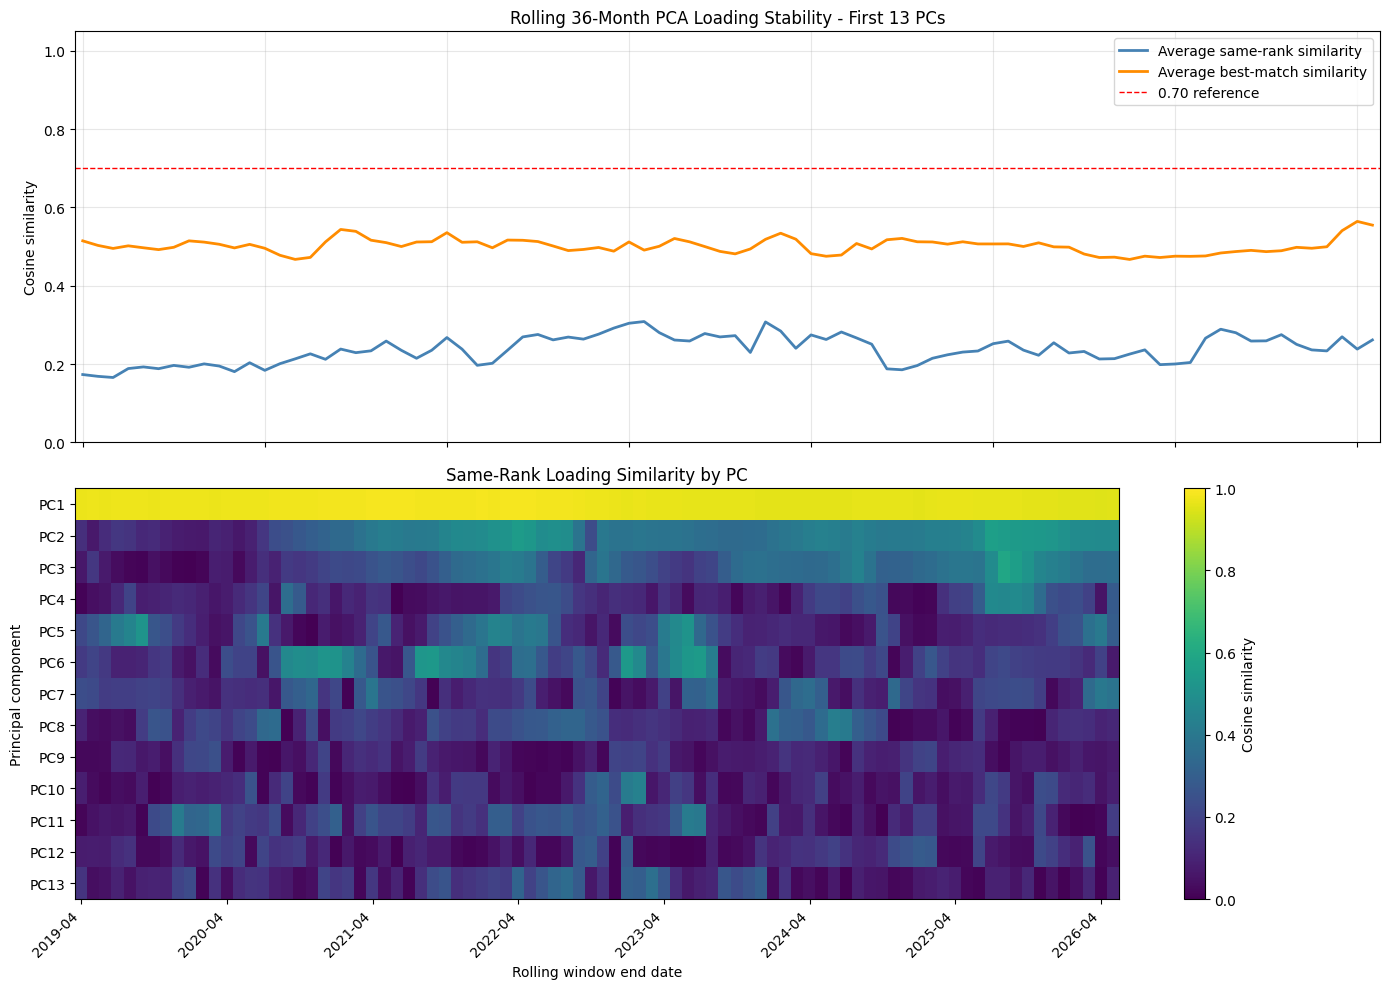

In [12]:
# Visualize rolling loading stability.
# Integer window positions keep the line plot and heatmap aligned on a shared x-axis.
x_pos = np.arange(len(same_rank_stability.index))
xticks = np.arange(0, len(same_rank_stability.index), 12)
xtick_labels = [same_rank_stability.index[i].strftime("%Y-%m") for i in xticks]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(
    x_pos,
    same_rank_stability.mean(axis=1).to_numpy(),
    color="steelblue",
    linewidth=2,
    label="Average same-rank similarity",
)
axes[0].plot(
    x_pos,
    best_match_stability.mean(axis=1).to_numpy(),
    color="darkorange",
    linewidth=2,
    label="Average best-match similarity",
)
axes[0].axhline(0.7, color="red", linestyle="--", linewidth=1, label="0.70 reference")
axes[0].set_title("Rolling 36-Month PCA Loading Stability - First 13 PCs")
axes[0].set_ylabel("Cosine similarity")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(
    same_rank_stability.T,
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
)
axes[1].set_yticks(range(N_STABILITY_PCS))
axes[1].set_yticklabels(score_cols)
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(xtick_labels, rotation=45, ha="right")
axes[1].set_title("Same-Rank Loading Similarity by PC")
axes[1].set_xlabel("Rolling window end date")
axes[1].set_ylabel("Principal component")
plt.colorbar(im, ax=axes[1], label="Cosine similarity")

plt.tight_layout()
plt.show()
